# An Exploration of NYC Public Schools

### Python Project 1

**Research Question:**  
How does the mean Regents exam score at Stuyvesant High School compare with the NYC average?

**Exam:** Common Core Algebra  
**Year:** 2017

## Introduction

The goal of this project is to explore student performance on the New York City Regents exams. I will compare the mean score for Stuyvesant High School with the mean score for schools across NYC on the 2017 Common Core Algebra Regents exam.

## 1. Load the Data

The dataset contains school-level Regents exam results for NYC public schools from 2015 to 2017.

## 2. Data Cleaning

The `Mean Score` column contained some non-numeric values such as `"s"`. I converted the column to numeric values and changed values that could not be converted to missing values.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv"

df = pd.read_csv(url)

df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


## 2. Data Cleaning

The `Mean Score` column contained some non-numeric values such as `"s"`. I converted the column to numeric values and changed values that could not be converted to missing values.

In [3]:
df["Mean Score"] = pd.to_numeric(df["Mean Score"], errors="coerce")

df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,NaN,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74.0,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,NaN,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,NaN,s,s,s,s,s,s,na,na


## 3. Descriptive Statistics

The descriptive statistics below show the distribution of mean Regents scores in the dataset.

In [4]:
df["Mean Score"].describe()

,Mean Score
count,137109.000000
mean,65.998967
std,11.288883
min,15.000000
25%,58.300000
50%,65.400000
75%,73.400000
max,98.700000


In [5]:
df[df["School Name"].str.contains("Stuyvesant", case=False, na=False)]["School Name"].unique()

array(['Stuyvesant High School',
       'Bedford Stuyvesant Preparatory High School',
       'Leadership Prep Bedford Stuyvesant Uncommon Prep C',
       'Bedford Stuyvesant Collegiate Charter School',
       'Bedford Stuyvesant New Beginnings Charter School'], dtype=object)

In [6]:
stuy = df[df["School Name"] == "Stuyvesant High School"]

stuy[["School Name", "Regents Exam", "Year", "Total Tested", "Mean Score"]].head(20)

,School Name,Regents Exam,Year,Total Tested,Mean Score
1511,Stuyvesant High School,Algebra2/Trigonometry,2015,875,92.9
1512,Stuyvesant High School,Algebra2/Trigonometry,2016,792,93.1
1513,Stuyvesant High School,Common Core Algebra,2015,35,82.3
1514,Stuyvesant High School,Common Core Algebra,2016,144,89.5
1515,Stuyvesant High School,Common Core Algebra,2017,63,93.9
1516,Stuyvesant High School,Common Core Algebra2,2016,785,84.2
1517,Stuyvesant High School,Common Core Algebra2,2017,796,87.3
1518,Stuyvesant High School,Common Core English,2016,828,92.4
1519,Stuyvesant High School,Common Core English,2017,824,93.9
1520,Stuyvesant High School,Common Core Geometry,2015,785,91.5


In [7]:
algebra_2017 = df[
    (df["Regents Exam"] == "Common Core Algebra") &
    (df["Year"] == 2017)
]

algebra_2017.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,NaN,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,NaN,s,s,s,s,s,s,na,na
10,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2017,51,84.8,0,0,51,100,44,86.3,50,98
14,01M188,P.S. 188 The Island School,K-8,Common Core Algebra,2017,20,67.4,7,35,13,65,1,5,10,50
22,01M292,Orchard Collegiate Academy,High school,Common Core Algebra,2017,53,67.5,15,28.3,38,71.7,6,11.3,29,54.7


In [8]:
stuy_score = algebra_2017[
    algebra_2017["School Name"] == "Stuyvesant High School"
]

stuy_score[["School Name", "Regents Exam", "Year", "Total Tested", "Mean Score"]]

,School Name,Regents Exam,Year,Total Tested,Mean Score
1515,Stuyvesant High School,Common Core Algebra,2017,63,93.9
22189,Stuyvesant High School,Common Core Algebra,2017,62,NaN
22190,Stuyvesant High School,Common Core Algebra,2017,1,NaN
58019,Stuyvesant High School,Common Core Algebra,2017,44,94.0
58020,Stuyvesant High School,Common Core Algebra,2017,19,93.6
105744,Stuyvesant High School,Common Core Algebra,2017,20,94.8
105745,Stuyvesant High School,Common Core Algebra,2017,43,93.5
145989,Stuyvesant High School,Common Core Algebra,2017,42,93.7
145990,Stuyvesant High School,Common Core Algebra,2017,1,NaN
145991,Stuyvesant High School,Common Core Algebra,2017,1,NaN


### Common Core Algebra — 2017

For the comparison, I focused on the 2017 Common Core Algebra Regents exam. There were 7,068 valid mean scores in the dataset, with an average score of 69.96.

In [9]:
algebra_2017["Mean Score"].describe()

,Mean Score
count,7068.000000
mean,69.963809
std,9.759105
min,37.200000
25%,62.575000
50%,68.500000
75%,76.900000
max,96.600000


In [10]:
nyc_average = algebra_2017["Mean Score"].mean()
stuy_average = stuy_score["Mean Score"].iloc[0]

difference = stuy_average - nyc_average

print("Stuyvesant Mean Score:", stuy_average)
print("NYC Mean Score:", round(nyc_average, 2))
print("Difference:", round(difference, 2))

Stuyvesant Mean Score: 93.9
NYC Mean Score: 69.96
Difference: 23.94


## 4. Stuyvesant High School vs. NYC Average

I selected Stuyvesant High School as the school for comparison. Its 2017 Common Core Algebra mean score was compared with the average mean score for schools across NYC taking the same exam in the same year.

In [11]:
comparison = pd.DataFrame({
    "School": ["Stuyvesant High School", "NYC Average"],
    "Mean Score": [stuy_average, nyc_average]
})

comparison

,School,Mean Score
0,Stuyvesant High School,93.900000
1,NYC Average,69.963809


## 5. Visualization

The bar chart below compares the mean score at Stuyvesant High School with the NYC average.

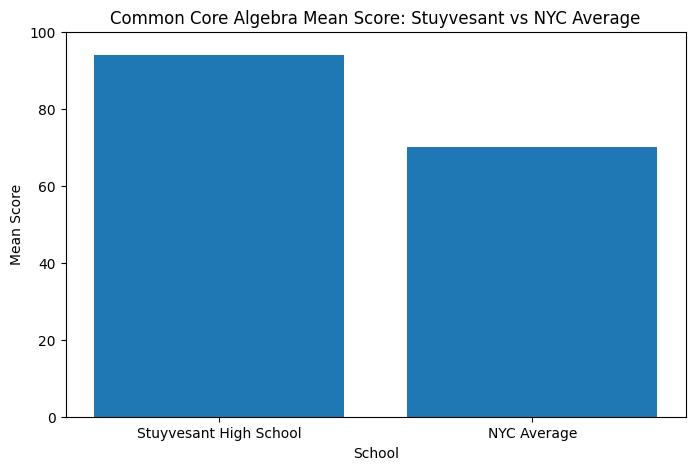

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(comparison["School"], comparison["Mean Score"])

plt.title("Common Core Algebra Mean Score: Stuyvesant vs NYC Average")
plt.xlabel("School")
plt.ylabel("Mean Score")

plt.ylim(0, 100)

plt.show()

## 6. Conclusion

Stuyvesant High School had a substantially higher mean score on the 2017 Common Core Algebra Regents exam than the NYC average. Stuyvesant's mean score was 93.9 compared with the NYC average of 69.96, a difference of about 23.9 points.